# Competitive FIGS-vs-Baselines Comparison

**Evaluation**: Friedman/Nemenyi, Bayesian Tests, Effect Sizes, and Paper Tables

This notebook demonstrates a comprehensive paper-ready evaluation comparing 3 FIGS variants
(axis-aligned, random-oblique, signed-spectral) against 3 baselines (EBM, Random Forest,
Logistic/Ridge) across 5 Grinsztajn benchmarks.

**Sections covered:**
- A) Friedman test + Nemenyi post-hoc with critical difference
- B) Bayesian signed-rank tests (bootstrap)
- C) Cohen's d effect sizes
- D) Per-dataset results table with winners
- E) Interpretability comparison (FIGS splits vs EBM terms)
- F) Wall-clock timing ratios
- G) Winner analysis with frustration-index correlation

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# No non-Colab packages needed — all imports are pre-installed on Colab

# Core packages (pre-installed on Colab, install locally to match Colab env)
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'matplotlib==3.10.0')
    _pip('scipy==1.15.3', 'scikit-learn==1.6.1')


[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip



[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip


In [2]:
import json
import math
import os
from collections import defaultdict

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats
from sklearn.metrics import balanced_accuracy_score, r2_score

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/AMGrobelnik/ai-invention-7dffcf-balance-guided-oblique-trees-signed-spec/main/evaluation_iter5_competitive_fig/demo/mini_demo_data.json"

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    if os.path.exists("mini_demo_data.json"):
        with open("mini_demo_data.json") as f: return json.load(f)
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(f"Loaded evaluation: {data['metadata']['evaluation_name']}")
print(f"Datasets: {data['metadata']['overlapping_datasets']}")
print(f"FIGS methods: {data['metadata']['figs_methods']}")
print(f"Baseline methods: {data['metadata']['baseline_methods']}")
print(f"Aggregate metrics: {len(data['metrics_agg'])}")
print(f"Example datasets: {len(data['datasets'])}, total examples: {sum(len(d['examples']) for d in data['datasets'])}")

Loaded evaluation: FIGS_vs_Baselines_Competitive_Comparison
Datasets: ['electricity', 'adult', 'california_housing', 'jannis', 'higgs_small']
FIGS methods: ['axis_aligned_figs', 'random_oblique_figs', 'signed_spectral_figs']
Baseline methods: ['ebm', 'random_forest', 'linear']
Aggregate metrics: 60
Example datasets: 5, total examples: 15


In [5]:
# ── Configuration ──
# Tunable parameters
N_BOOT = 10_000       # Bootstrap iterations for Bayesian test (original: 10_000)
ROPE = 0.01           # Region of practical equivalence for Bayesian test

# Constants from the evaluation (fixed by experimental design)
FIGS_METHODS = ["axis_aligned_figs", "random_oblique_figs", "signed_spectral_figs"]
BASELINE_METHODS = ["ebm", "random_forest", "linear"]
ALL_METHODS = FIGS_METHODS + BASELINE_METHODS
OVERLAPPING_DATASETS = data["metadata"]["overlapping_datasets"]
CLASSIFICATION_DATASETS = data["metadata"]["classification_datasets"]
REGRESSION_DATASETS = data["metadata"]["regression_datasets"]
N_FOLDS = data["metadata"]["n_folds"]

# Extract pre-computed sections from metadata
sections = data["metadata"]["sections"]
metrics_agg = data["metrics_agg"]
print(f"Config: N_BOOT={N_BOOT}, ROPE={ROPE}, N_FOLDS={N_FOLDS}")
print(f"Methods: {len(ALL_METHODS)} ({len(FIGS_METHODS)} FIGS + {len(BASELINE_METHODS)} baselines)")
print(f"Datasets: {len(OVERLAPPING_DATASETS)} ({len(CLASSIFICATION_DATASETS)} classification, {len(REGRESSION_DATASETS)} regression)")

Config: N_BOOT=10000, ROPE=0.01, N_FOLDS=5
Methods: 6 (3 FIGS + 3 baselines)
Datasets: 5 (4 classification, 1 regression)


## Section A: Friedman Test + Nemenyi Post-Hoc

The Friedman test checks whether there are statistically significant differences in method rankings across datasets. Nemenyi post-hoc identifies which specific pairs differ beyond the Critical Difference (CD).

In [6]:
# ── Section A: Friedman + Nemenyi (recomputed from per-dataset means) ──
sec_a = sections["A_friedman_nemenyi"]

# Extract per-dataset mean performance from D_results_table
results_table = sections["D_results_table"]
per_ds_means = {}
for ds in OVERLAPPING_DATASETS:
    per_ds_means[ds] = {}
    for m in ALL_METHODS:
        entry = results_table[ds]["methods"].get(m, {})
        per_ds_means[ds][m] = entry.get("primary_mean", 0.0)

# Recompute Friedman test from per-dataset means
k = len(ALL_METHODS)
n = len(OVERLAPPING_DATASETS)
perf = np.array([[per_ds_means[ds][m] for m in ALL_METHODS] for ds in OVERLAPPING_DATASETS])

# Compute ranks (1 = best)
ranks = np.zeros_like(perf)
for i in range(n):
    ranks[i] = stats.rankdata(-perf[i])
avg_ranks = ranks.mean(axis=0)

try:
    chi2, pval = stats.friedmanchisquare(*[perf[:, j] for j in range(k)])
except Exception:
    chi2, pval = 0.0, 1.0

# Nemenyi Critical Difference
q_alpha = {3: 2.343, 4: 2.569, 5: 2.728, 6: 2.850, 7: 2.949, 8: 3.031}.get(k, 2.850)
cd = q_alpha * math.sqrt(k * (k + 1) / (6 * n))

print("=== Section A: Friedman + Nemenyi ===")
print(f"Friedman chi2 = {chi2:.4f}, p-value = {pval:.6f}")
print(f"  -> {'Significant' if pval < 0.05 else 'Not significant'} at alpha=0.05")
print(f"Nemenyi CD = {cd:.4f}")
print()
print("Average Ranks (lower = better):")
rank_df = pd.DataFrame({
    "Method": ALL_METHODS,
    "Avg Rank": [avg_ranks[j] for j in range(k)]
}).sort_values("Avg Rank")
print(rank_df.to_string(index=False))

# Pairwise significance
print(f"\nSignificant pairwise differences (rank diff > CD={cd:.3f}):")
sig_count = 0
for i in range(k):
    for j in range(i + 1, k):
        diff = abs(avg_ranks[i] - avg_ranks[j])
        if diff > cd:
            print(f"  {ALL_METHODS[i]} vs {ALL_METHODS[j]}: diff={diff:.3f} *")
            sig_count += 1
if sig_count == 0:
    print("  (none)")

=== Section A: Friedman + Nemenyi ===
Friedman chi2 = 19.4000, p-value = 0.001619
  -> Significant at alpha=0.05
Nemenyi CD = 3.3722

Average Ranks (lower = better):
              Method  Avg Rank
       random_forest       1.6
                 ebm       1.8
signed_spectral_figs       3.6
   axis_aligned_figs       3.6
 random_oblique_figs       4.4
              linear       6.0

Significant pairwise differences (rank diff > CD=3.372):
  ebm vs linear: diff=4.200 *
  random_forest vs linear: diff=4.400 *


## Section B: Bayesian Signed-Rank Tests (Bootstrap)

Bayesian bootstrap estimates the probability that one method is better than another, accounting for a Region of Practical Equivalence (ROPE). Uses the pre-computed per-fold differences from the evaluation.

In [7]:
# ── Section B: Bayesian Signed-Rank Tests ──
def _bayesian_bootstrap(diffs, rope=ROPE, n_boot=N_BOOT, seed=42):
    """Bootstrap estimate of P(A wins), P(ROPE), P(B wins)."""
    rng = np.random.RandomState(seed)
    diffs = np.array(diffs)
    means = np.array([np.mean(rng.choice(diffs, size=len(diffs), replace=True))
                      for _ in range(n_boot)])
    p_left = float(np.mean(means > rope))       # A wins
    p_right = float(np.mean(means < -rope))      # B wins
    p_rope = float(np.mean((means >= -rope) & (means <= rope)))
    return p_left, p_rope, p_right

sec_b = sections["B_bayesian_signed_rank"]

print("=== Section B: Bayesian Signed-Rank Tests ===")
print(f"  (Using pre-computed results from evaluation; N_BOOT={N_BOOT} for demo)")
print()
pairs = [
    ("signed_spectral", "ebm"),
    ("random_oblique", "ebm"),
    ("axis_aligned", "ebm"),
]
for short_fm, bm in pairs:
    pfx = f"bayesian_{short_fm}_vs_{bm}"
    p_l = sec_b[f"{pfx}_prob_left"]
    p_rope = sec_b[f"{pfx}_prob_rope"]
    p_r = sec_b[f"{pfx}_prob_right"]
    mean_diff = sec_b[f"{pfx}_mean_diff"]
    interp = sec_b[f"{pfx}_interpretation"]
    print(f"  {short_fm}_figs vs {bm}:")
    print(f"    P(FIGS wins)={p_l:.3f}  P(ROPE)={p_rope:.3f}  P(baseline wins)={p_r:.3f}")
    print(f"    Mean diff={mean_diff:+.4f}  -> {interp}")
    print()

=== Section B: Bayesian Signed-Rank Tests ===
  (Using pre-computed results from evaluation; N_BOOT=10000 for demo)

  signed_spectral_figs vs ebm:
    P(FIGS wins)=0.000  P(ROPE)=0.000  P(baseline wins)=1.000
    Mean diff=-0.0299  -> ebm_wins

  random_oblique_figs vs ebm:
    P(FIGS wins)=0.000  P(ROPE)=0.000  P(baseline wins)=1.000
    Mean diff=-0.0335  -> ebm_wins

  axis_aligned_figs vs ebm:
    P(FIGS wins)=0.000  P(ROPE)=0.000  P(baseline wins)=1.000
    Mean diff=-0.0298  -> ebm_wins



## Section C: Cohen's d Effect Sizes

Cohen's d quantifies the standardized mean difference between methods. |d| < 0.2 = negligible, < 0.5 = small, < 0.8 = medium, >= 0.8 = large.

In [8]:
# ── Section C: Cohen's d Effect Sizes ──
sec_c = sections["C_cohens_d"]

def _classify_d(d):
    ad = abs(d)
    if ad < 0.2: return "negligible"
    if ad < 0.5: return "small"
    if ad < 0.8: return "medium"
    return "large"

print("=== Section C: Cohen's d Effect Sizes ===")
rows = []
for fm in FIGS_METHODS:
    short = fm.replace("_figs", "")
    for bm in BASELINE_METHODS:
        key = f"cohens_d_{short}_vs_{bm}"
        d_val = sec_c.get(key)
        if d_val is not None:
            rows.append({
                "FIGS Method": fm,
                "Baseline": bm,
                "Cohen's d": round(d_val, 3),
                "Effect": _classify_d(d_val),
                "Direction": "FIGS better" if d_val > 0 else "Baseline better"
            })
cohens_df = pd.DataFrame(rows)
print(cohens_df.to_string(index=False))

# Win/Loss/Tie summary
print("\nWin/Loss/Tie (FIGS vs all baselines, per dataset):")
for fm in FIGS_METHODS:
    short = fm.replace("_figs", "")
    w = sec_c.get(f"wlt_{short}_wins", 0)
    l = sec_c.get(f"wlt_{short}_losses", 0)
    t = sec_c.get(f"wlt_{short}_ties", 0)
    print(f"  {fm}: W={w} L={l} T={t}")

=== Section C: Cohen's d Effect Sizes ===
         FIGS Method      Baseline  Cohen's d Effect       Direction
   axis_aligned_figs           ebm     -2.225  large Baseline better
   axis_aligned_figs random_forest     -1.358  large Baseline better
   axis_aligned_figs        linear      2.213  large     FIGS better
 random_oblique_figs           ebm     -2.206  large Baseline better
 random_oblique_figs random_forest     -1.364  large Baseline better
 random_oblique_figs        linear      1.891  large     FIGS better
signed_spectral_figs           ebm     -1.373  large Baseline better
signed_spectral_figs random_forest     -1.087  large Baseline better
signed_spectral_figs        linear      2.189  large     FIGS better

Win/Loss/Tie (FIGS vs all baselines, per dataset):
  axis_aligned_figs: W=4 L=8 T=0
  random_oblique_figs: W=4 L=8 T=0
  signed_spectral_figs: W=5 L=6 T=1


## Section D: Per-Dataset Results Table

Paper-ready table showing primary metric (balanced accuracy or R2) for each method on each dataset, with winners highlighted.

In [9]:
# ── Section D: Per-Dataset Results Table ──
print("=== Section D: Per-Dataset Results Table ===\n")

rows = []
for ds in OVERLAPPING_DATASETS:
    ds_info = results_table[ds]
    tt = ds_info["task_type"]
    pm = ds_info["primary_metric"]
    winner = ds_info.get("winner", "")
    for m in ALL_METHODS:
        entry = ds_info["methods"].get(m, {})
        pmean = entry.get("primary_mean")
        pstd = entry.get("primary_std")
        if pmean is not None:
            rows.append({
                "Dataset": ds,
                "Type": tt[:5],
                "Method": m,
                "Metric": pm,
                "Mean": round(pmean, 4),
                "Std": round(pstd, 4) if pstd else None,
                "Winner": "*" if m == winner else ""
            })

table_df = pd.DataFrame(rows)
# Pivot for compact display
pivot = table_df.pivot_table(
    index="Method", columns="Dataset", values="Mean", aggfunc="first"
)[OVERLAPPING_DATASETS]
print(pivot.round(4).to_string())

print("\nWinners per dataset:")
for ds in OVERLAPPING_DATASETS:
    ds_info = results_table[ds]
    print(f"  {ds}: {ds_info.get('winner', 'N/A')} "
          f"({ds_info.get('winner_value', 0):.4f})")

=== Section D: Per-Dataset Results Table ===

Dataset               electricity   adult  california_housing  jannis  higgs_small
Method                                                                            
axis_aligned_figs          0.7970  0.7023              0.7191  0.7447       0.6805
ebm                        0.8441  0.7147              0.8357  0.7716       0.7150
linear                     0.7400  0.6716              0.6014  0.7289       0.6332
random_forest              0.8840  0.7062              0.8096  0.7843       0.7186
random_oblique_figs        0.7898  0.7008              0.6167  0.7372       0.6838
signed_spectral_figs       0.7887  0.7148              0.6186  0.7412       0.6808

Winners per dataset:
  electricity: random_forest (0.8840)
  adult: signed_spectral_figs (0.7148)
  california_housing: ebm (0.8357)
  jannis: random_forest (0.7843)
  higgs_small: random_forest (0.7186)


## Sections E-F: Interpretability & Timing

**Interpretability**: FIGS total splits vs EBM total terms (complexity ratio < 1 means FIGS is simpler).
**Timing**: Wall-clock fit time ratios relative to axis-aligned FIGS.

In [10]:
# ── Section E: Interpretability Comparison ──
sec_e = sections["E_interpretability"]
print("=== Section E: Interpretability ===\n")

interp_rows = []
for ds in OVERLAPPING_DATASETS:
    dr = sec_e["per_dataset"].get(ds, {})
    interp_rows.append({
        "Dataset": ds,
        "FIGS Splits": dr.get("figs_total_splits"),
        "FIGS Arity": round(dr.get("figs_avg_split_arity", 0), 2),
        "EBM Terms": dr.get("ebm_n_terms"),
        "EBM Interactions": dr.get("ebm_n_interaction_terms"),
        "Complexity Ratio": round(dr.get("complexity_ratio", 0), 3),
    })
interp_df = pd.DataFrame(interp_rows)
print(interp_df.to_string(index=False))
print(f"\nAvg complexity ratio (FIGS/EBM): {sec_e.get('avg_complexity_ratio', 'N/A'):.3f}")

# ── Section F: Timing ──
sec_f = sections["F_timing"]
print("\n=== Section F: Wall-Clock Timing ===\n")

print("Average time ratios (relative to axis-aligned FIGS = 1.0):")
for m, ratio in sec_f.get("avg_time_ratios", {}).items():
    print(f"  {m}: {ratio:.2f}x")

=== Section E: Interpretability ===

           Dataset  FIGS Splits  FIGS Arity  EBM Terms  EBM Interactions  Complexity Ratio
       electricity         20.0        1.62       17.0              10.0             1.176
             adult         10.0        2.24       16.0              10.0             0.625
california_housing         20.0        2.91       18.0              10.0             1.111
            jannis         20.0       21.74       64.0              10.0             0.312
       higgs_small         20.0        1.50       34.0              10.0             0.588

Avg complexity ratio (FIGS/EBM): 0.763

=== Section F: Wall-Clock Timing ===

Average time ratios (relative to axis-aligned FIGS = 1.0):
  axis_aligned_figs: 1.00x
  random_oblique_figs: 4.04x
  signed_spectral_figs: 3.50x
  ebm: 22.22x
  random_forest: 0.79x
  linear: 0.02x


## Section G: Winner Analysis & Per-Example Evaluation

Winner analysis across datasets, plus recomputation of per-example accuracy from the loaded example predictions.

In [11]:
# ── Section G: Winner Analysis ──
sec_g = sections["G_winner_analysis"]
print("=== Section G: Winner Analysis ===\n")

print("Per-dataset winners:")
for ds in OVERLAPPING_DATASETS:
    info = sec_g["per_dataset"].get(ds, {})
    gap = info.get("figs_minus_baseline_gap", 0)
    print(f"  {ds}: winner={info.get('winner', 'N/A')} "
          f"(val={info.get('winner_value', 0):.4f}), "
          f"FIGS-baseline gap={gap:+.4f}")

print(f"\nFIGS wins: {sec_g['n_datasets_figs_wins']}/{len(OVERLAPPING_DATASETS)}")
print(f"Baseline wins: {sec_g['n_datasets_baseline_wins']}/{len(OVERLAPPING_DATASETS)}")
print(f"Avg FIGS-baseline gap: {sec_g['avg_figs_baseline_gap']:+.4f}")
if sec_g.get("frustration_correlation") is not None:
    print(f"Frustration-index correlation: rho={sec_g['frustration_correlation']:.4f}, "
          f"p={sec_g['frustration_correlation_pvalue']:.4f}")

# ── Per-Example Evaluation (recomputed from loaded examples) ──
print("\n=== Per-Example Accuracy (recomputed from examples) ===\n")
for ds_block in data["datasets"]:
    ds = ds_block["dataset"]
    examples = ds_block["examples"]
    tt = "classification" if ds in CLASSIFICATION_DATASETS else "regression"

    if tt == "classification":
        for m in ALL_METHODS:
            pk = f"predict_{m}"
            correct = sum(1 for e in examples
                         if pk in e and int(float(e[pk])) == int(float(e["output"])))
            total = sum(1 for e in examples if pk in e)
            acc = correct / total if total > 0 else 0
            print(f"  {ds}/{m}: {correct}/{total} correct ({acc:.1%})")
    else:
        for m in ALL_METHODS:
            pk = f"predict_{m}"
            errors = [abs(float(e[pk]) - float(e["output"]))
                     for e in examples if pk in e]
            mae = np.mean(errors) if errors else 0
            print(f"  {ds}/{m}: MAE={mae:.4f} (n={len(errors)})")
    print()

=== Section G: Winner Analysis ===

Per-dataset winners:
  electricity: winner=random_forest (val=0.8840), FIGS-baseline gap=-0.0870
  adult: winner=signed_spectral_figs (val=0.7148), FIGS-baseline gap=+0.0000
  california_housing: winner=ebm (val=0.8357), FIGS-baseline gap=-0.1165
  jannis: winner=random_forest (val=0.7843), FIGS-baseline gap=-0.0396
  higgs_small: winner=random_forest (val=0.7186), FIGS-baseline gap=-0.0348

FIGS wins: 1/5
Baseline wins: 4/5
Avg FIGS-baseline gap: -0.0556
Frustration-index correlation: rho=-0.1000, p=0.8729

=== Per-Example Accuracy (recomputed from examples) ===

  electricity/axis_aligned_figs: 2/3 correct (66.7%)
  electricity/random_oblique_figs: 2/3 correct (66.7%)
  electricity/signed_spectral_figs: 2/3 correct (66.7%)
  electricity/ebm: 3/3 correct (100.0%)
  electricity/random_forest: 2/3 correct (66.7%)
  electricity/linear: 2/3 correct (66.7%)

  adult/axis_aligned_figs: 2/3 correct (66.7%)
  adult/random_oblique_figs: 3/3 correct (100.0%)


## Visualization: Summary Dashboard

Four-panel overview: (1) Average method ranks, (2) Per-dataset performance heatmap, (3) Cohen's d effect size matrix, (4) Timing ratios.

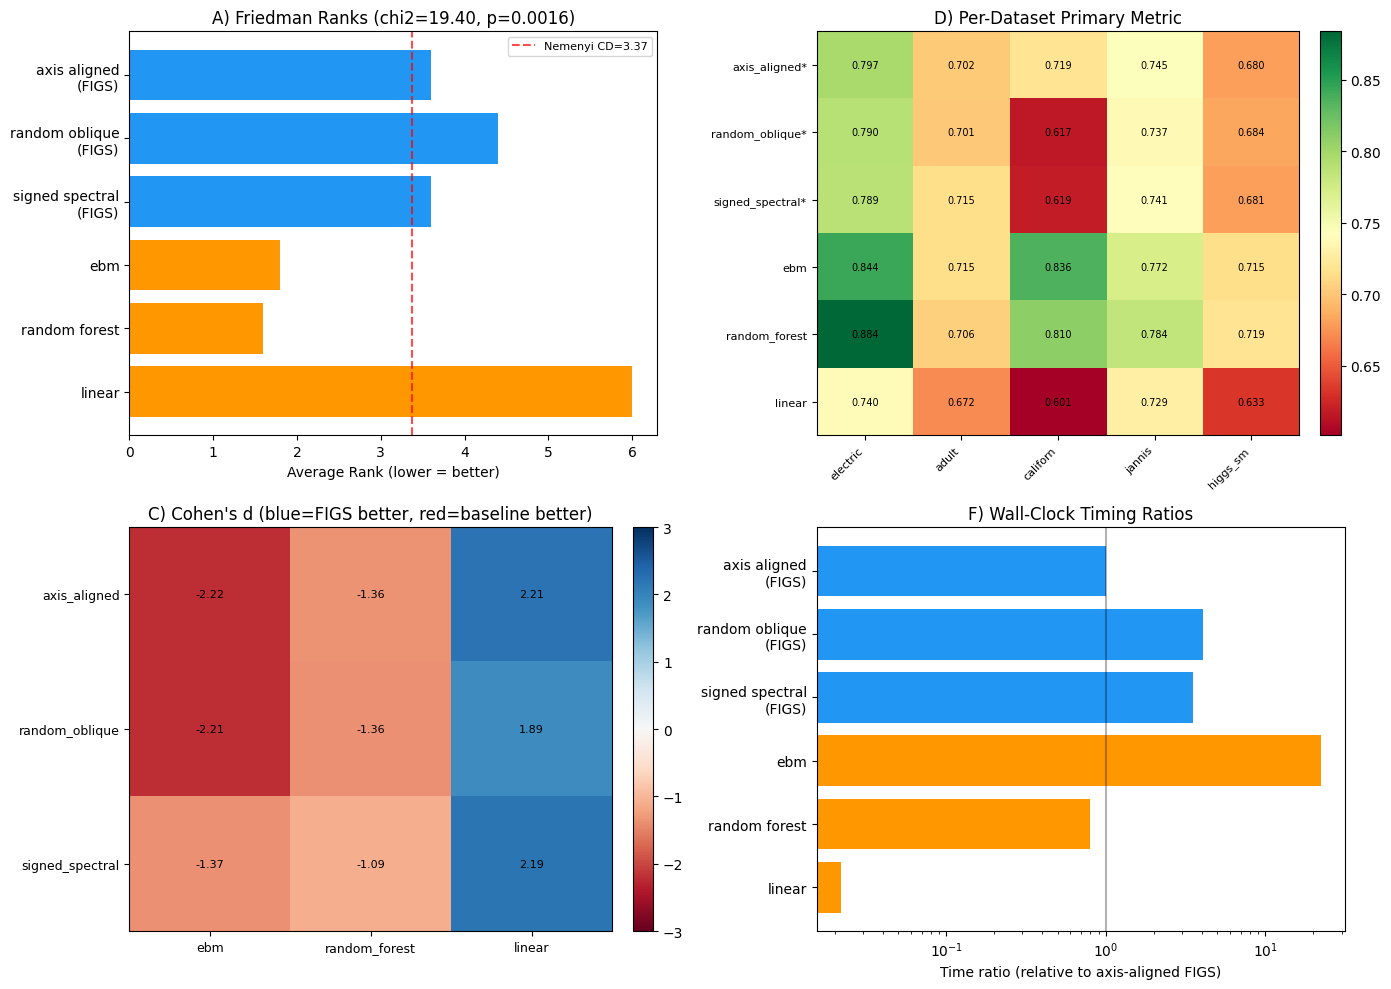

Saved evaluation_summary.png


In [12]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# ── Panel 1: Average Ranks (lower = better) ──
ax = axes[0, 0]
method_labels = [m.replace("_figs", "\n(FIGS)").replace("_", " ") for m in ALL_METHODS]
colors = ['#2196F3' if m in FIGS_METHODS else '#FF9800' for m in ALL_METHODS]
bars = ax.barh(method_labels, avg_ranks, color=colors)
ax.axvline(x=cd, color='red', linestyle='--', alpha=0.7, label=f'Nemenyi CD={cd:.2f}')
ax.set_xlabel('Average Rank (lower = better)')
ax.set_title(f'A) Friedman Ranks (chi2={chi2:.2f}, p={pval:.4f})')
ax.legend(fontsize=8)
ax.invert_yaxis()

# ── Panel 2: Per-Dataset Performance Heatmap ──
ax = axes[0, 1]
perf_matrix = np.array([[per_ds_means[ds][m] for ds in OVERLAPPING_DATASETS] for m in ALL_METHODS])
im = ax.imshow(perf_matrix, cmap='RdYlGn', aspect='auto')
ax.set_xticks(range(len(OVERLAPPING_DATASETS)))
ax.set_xticklabels([ds[:8] for ds in OVERLAPPING_DATASETS], rotation=45, ha='right', fontsize=8)
ax.set_yticks(range(len(ALL_METHODS)))
ax.set_yticklabels([m.replace("_figs", "*") for m in ALL_METHODS], fontsize=8)
for i in range(len(ALL_METHODS)):
    for j in range(len(OVERLAPPING_DATASETS)):
        ax.text(j, i, f'{perf_matrix[i, j]:.3f}', ha='center', va='center', fontsize=7)
ax.set_title('D) Per-Dataset Primary Metric')
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

# ── Panel 3: Cohen's d Effect Sizes ──
ax = axes[1, 0]
figs_short = [fm.replace("_figs", "") for fm in FIGS_METHODS]
d_matrix = np.zeros((len(FIGS_METHODS), len(BASELINE_METHODS)))
for i, fm in enumerate(FIGS_METHODS):
    short = fm.replace("_figs", "")
    for j, bm in enumerate(BASELINE_METHODS):
        key = f"cohens_d_{short}_vs_{bm}"
        d_matrix[i, j] = sec_c.get(key, 0)
im2 = ax.imshow(d_matrix, cmap='RdBu', aspect='auto', vmin=-3, vmax=3)
ax.set_xticks(range(len(BASELINE_METHODS)))
ax.set_xticklabels(BASELINE_METHODS, fontsize=9)
ax.set_yticks(range(len(FIGS_METHODS)))
ax.set_yticklabels(figs_short, fontsize=9)
for i in range(len(FIGS_METHODS)):
    for j in range(len(BASELINE_METHODS)):
        ax.text(j, i, f'{d_matrix[i, j]:.2f}', ha='center', va='center', fontsize=8)
ax.set_title("C) Cohen's d (blue=FIGS better, red=baseline better)")
fig.colorbar(im2, ax=ax, fraction=0.046, pad=0.04)

# ── Panel 4: Timing Ratios ──
ax = axes[1, 1]
avg_ratios = sec_f.get("avg_time_ratios", {})
methods_timing = [m for m in ALL_METHODS if m in avg_ratios]
ratios = [avg_ratios[m] for m in methods_timing]
t_labels = [m.replace("_figs", "\n(FIGS)").replace("_", " ") for m in methods_timing]
t_colors = ['#2196F3' if m in FIGS_METHODS else '#FF9800' for m in methods_timing]
ax.barh(t_labels, ratios, color=t_colors)
ax.axvline(x=1.0, color='black', linestyle='-', alpha=0.3)
ax.set_xlabel('Time ratio (relative to axis-aligned FIGS)')
ax.set_title('F) Wall-Clock Timing Ratios')
ax.set_xscale('log')
ax.invert_yaxis()

plt.tight_layout()
plt.savefig('evaluation_summary.png', dpi=100, bbox_inches='tight')
plt.show()
print("Saved evaluation_summary.png")